## Lorenz96モデルの実装

In [2]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Lorenz96モデルの定義
def L96(x, F):
    """
    x: shape (N,) または (N, M)
    F: スカラーまたは shape (N, 1/ M とブロードキャスト可能)
    """
    x = np.asarray(x)
    roll_p1 = np.roll(x, -1, axis=0)
    roll_m1 = np.roll(x, 1, axis=0)
    roll_m2 = np.roll(x, 2, axis=0)
    return (roll_p1 - roll_m2) * roll_m1 - x + F
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F) * dt
    k2 = L96(x + 0.5 * k1, F) * dt
    k3 = L96(x + 0.5 * k2, F) * dt
    k4 = L96(x + k3, F) * dt
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2-1] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

# 与えらえたNの個数に基づいて、変数j個×N個のガウシアンノイズをリストで返すメソッド
def generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0):
    """
    N個のガウシアンノイズを生成する関数
    N: ノイズの個数
    mean: ノイズの平均値
    std: ノイズの標準偏差
    """
    return [np.random.normal(mean, std, j) for _ in range(N)]

def make_homogeneous_H(n, p):
    """
    p x n の均等観測演算子 H を作成する。
    観測は状態ベクトル長 n の要素から均等間隔で p 個を選ぶ（重複しないよう int に丸める）。
    戻り値:
      H : ndarray, shape (p, n)  -- 観測演算子（選んだ要素に対応する行が単位ベクトル）
      indices : ndarray, shape (p,) -- 観測に使う状態インデックス（0-based）
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    # 均等にインデックスを決める（端点を含める）
    indices = np.linspace(0, n - 1, p, dtype=int)
    # インデックスが重複する場合は調整（微小ずらし）
    # （通常は p<=n なら重複は起きにくいが念のため）
    uniq, counts = np.unique(indices, return_counts=True)
    if uniq.size != indices.size:
        # 重複を解消する簡易処理：採用済みインデックスを避けつつ前方に埋める
        used = set()
        new_idx = []
        for v in indices:
            if v in used:
                # 前後を探索して未使用インデックスを探す
                left = v - 1
                right = v + 1
                found = None
                while left >= 0 or right < n:
                    if left >= 0 and left not in used:
                        found = left
                        break
                    if right < n and right not in used:
                        found = right
                        break
                    left -= 1
                    right += 1
                if found is None:
                    raise RuntimeError("Cannot resolve duplicate observation indices")
                new_idx.append(found)
                used.add(found)
            else:
                new_idx.append(int(v))
                used.add(int(v))
        indices = np.array(new_idx, dtype=int)
    H = np.zeros((p, n), dtype=float)
    for i, idx in enumerate(indices):
        H[i, idx] = 1.0
    return H

def make_dense_H(n, p, dense=False, random_scale=0.01, seed=None):
    """
    n: 状態次元
    p: 観測次元
    dense: True にすると、(i,i)=1 に加えて残りの要素を小さい乱数で埋める（"dense" 化）
    random_scale: dense=True のときの乱数標準偏差
    seed: 乱数シード（再現性が欲しいときに指定）
    戻り値:
      H: ndarray, shape (p, n)
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    H = np.zeros((p, n), dtype=float)
    # 最初の p 行について対角成分 (i,i) を 1 にする
    for i in range(p):
        H[i, i] = 1.0

    if dense:
        rng = np.random.default_rng(seed)
        # 対角の位置は上書きしないようマスクを作る
        mask = np.ones((p, n), dtype=bool)
        for i in range(p):
            mask[i, i] = False
        H[mask] = rng.normal(loc=0.0, scale=random_scale, size=mask.sum())

    return H

In [ ]:
from scipy.linalg import sqrtm
class EnKF_LETKF:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.02, loc_radius=5):
        """
        LETKFを初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差

        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N,N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p, self.p) * obs_error_std
        self.Z = None
        self.ensemble_mean = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None
        self.inflation_factor = inflation_factor
        self.L = self.localization_matrix(loc_radius=loc_radius)
        # Hが密行列(dense)の場合や特殊な配置の場合、obs_indicesの自動判定は注意が必要
        # ここでは「Hの各列がいずれかの観測に関与しているか」で判定している
        self.obs_indices = np.where(np.any(self.H, axis=0))[0]

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # For reproducibility
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除

    def localization_matrix(self, loc_radius):
        """Gaussian Functionでの局所化行列を作成する"""
        ### グリッド間距離の計算
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                if dist < 2*np.sqrt(10/3)*loc_radius:
                    # exp(- (dist / loc_radius)^2 / 2)  の形でガウシアン関数を適用
                    L[i, j] = np.exp(-0.5 * (dist / loc_radius) ** 2)
                else:
                    L[i, j] = 0.0
        return L
                    
    def forecast(self):
        """アンサンブルの予測ステップを実行する"""
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = self.step_model(self.ensemble[:, i])
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)
    def step_model(self, x):
        """モデルの1ステップ予測を実行する"""
        return rk4_step(x, self.F, self.dt)

    def analysis(self, observation):
        """アンサンブルの解析ステップを実行する"""
        # (1) Preparation Step
        # Zb = self.Z * np.sqrt(self.inflation_factor)
        Zb = self.Z * self.inflation_factor
        Yb = self.H @ Zb
        diff = self.H @ observation.reshape(-1, 1) - self.H @ self.ensemble_mean
        # (2) Local Analysis Step
        L = self.L # 局所化行列の取得
        Xa = np.zeros_like(self.ensemble)
        # Rの逆行列を事前に計算
        R_inv = np.linalg.inv(self.R)
        
        # エラーチェック用のフラグ
        has_error = False
        
        for i in range(self.N):
            # (2.1) Eigenvalue Decomposition with Localization
            # 局所化行列の取得
            loc_weights = L[i, :]
            loc_weights_obs = loc_weights[self.obs_indices]          # 長さ = 観測次元
            R_loc_inv = R_inv * loc_weights_obs[:, None]
            Pa_tilde_inv = np.eye(self.ensemble_size) + Yb.T @ R_loc_inv @ Yb
            
            try:
                D, C = np.linalg.eigh(Pa_tilde_inv)
            except np.linalg.LinAlgError:
                if not has_error: # 最初のエラーだけ詳細を表示
                    print(f"LinAlgError at grid point {i}")
                    print(f"Pa_tilde_inv max: {np.max(Pa_tilde_inv)}, min: {np.min(Pa_tilde_inv)}")
                    print(f"Contains NaNs: {np.isnan(Pa_tilde_inv).any()}")
                    print(f"Contains Infs: {np.isinf(Pa_tilde_inv).any()}")
                    has_error = True
                # エラー時は更新せず予測値をそのまま使う（あるいは例外を投げる）
                # ここでは例外を再送出する
                raise

            D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
            Pa_tilde = C @ np.diag(1.0 / D) @ C.T
            pa_tilde_sqrt = C @ D_inv_sqrt @ C.T
            # (2.2) Update Ensemble
            T = Pa_tilde @ Yb.T @ R_loc_inv @ diff + np.sqrt(self.ensemble_size - 1)* pa_tilde_sqrt
            Xa[i, :] = self.ensemble_mean[i, 0] + Zb[i, :] @ T
        # (3) Collect analysis Ensemble of all model grid points
        self.ensemble = Xa
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Za = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        
        self.P_analysis_list.append((Za @ Za.T).copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
            

    def calculate_rmse(self, true_states):
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse**2, axis=1))

    def calculate_spread(self):
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list

#### LETKFの数値実験
ETKFと同じ設定でメンバー数を変化させつつ、局所化半径とインフレーションを固定して性能を比較します。

In [4]:
# LETKF experiments matching the ETKF settings
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')
N = 40
F = 8.0
dt = 0.05
step_day = 0.2
assim_interval = 0.05
steps_per_assim = int(assim_interval / dt)
member_sizes = [8, 10, 20]
loc_radius = 4
inflation_factor = 1.03
results_dict = {}
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed()
for m in member_sizes:
    H = make_homogeneous_H(N, p=20)
    letkf = EnKF_LETKF(N=N, F=F, dt=dt, H=H, ensemble_size=m, obs_error_std=1.0, loc_radius=loc_radius, inflation_factor=inflation_factor)
    letkf.initialize_ensemble(spinup.x.copy())
    rmse_list = []
    spread_list = []
    for t in range(0, observed_states.shape[0], steps_per_assim):
        letkf.forecast()
        letkf.analysis(observed_states[t])
        if (t // steps_per_assim) % 10 == 0:
            print(f'LETKF with m={m}, time step {t} / {observed_states.shape[0]} completed.')
    rmse = letkf.calculate_rmse(true_states)
    spread = letkf.calculate_spread()
    rmse_list.append(rmse)
    spread_list.append(spread)
    results_dict[m] = {'rmse': rmse_list, 'spread': spread_list}
days = np.arange(observed_states.shape[0]) * dt / step_day
for m in member_sizes:
    plt.figure(figsize=(12, 6))
    plt.plot(days, results_dict[m]['rmse'][0], label='RMSE')
    plt.plot(days, results_dict[m]['spread'][0], label='Spread')
    plt.title(f'LETKF Results (m={m}, loc_radius={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%)', fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('Time Step (days)', fontsize=20)
    plt.ylabel('Value', fontsize=20)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()

Random steps for spinup: 1126


NameError: name 'EnKF_LETKF' is not defined

#### 観測地点数による比較

In [ ]:
# 縦軸inflation係数、横軸を局所化半径としててRMSEの平均値を色で表すヒートマップを作成するコード
import numpy as np
import seaborn as sns
from joblib import Parallel, delayed
import itertools

inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(2, 21)]  # 1から10.0まで0.5刻み
# rmse_matrixは後で num_obs ごとに作成するためここでは初期化しない
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 8  # メンバー数を固定
num_obs_list = [20, 25, 30, 35, 40]
# 結果の格納用辞書 (num_obs をキーに rmse_matrix を保存)
results_dict_all = {}
# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(38)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除

# 1回のシミュレーションを実行するワーカー関数
# num_obs を引数で受け取り、観測数ごとに H を作成する

def run_simulation(inflation_factor, loc_radius, num_obs):
    # スピンアップ後の初期状態をコピーして使用
    initial_state = spinup.x.copy()
    H = make_homogeneous_H(n=N, p=num_obs)
    enkf_serial_ensrf = EnKF_LETKF(N=N, F=F, H=H, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=inflation_factor, loc_radius=loc_radius)
    enkf_serial_ensrf.initialize_ensemble(initial_state)
    
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_serial_ensrf.forecast()
        enkf_serial_ensrf.analysis(observed_states[t])
        # progress を簡潔に表示
    
    rmse = enkf_serial_ensrf.calculate_rmse(true_states)
    spread = enkf_serial_ensrf.calculate_spread()

    # 10日目から300日目までの平均RMSEを計算
    start_idx = int(10 * (step_day / dt) / steps_per_assim)
    end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
    avg_rmse = np.mean(rmse[start_idx:end_idx])

    return inflation_factor, loc_radius, num_obs, avg_rmse, rmse, spread

# 外側で num_obs ごとに並列実行を行う
for num_obs in num_obs_list:
    print(f"Starting experiments for num_obs = {num_obs} (members={member_size})")
    rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))
    param_combinations = list(itertools.product(inflation_factors, loc_radius_list))
    # n_jobs=-1 は利用可能な全てのCPUコアを使用することを意味します
    results = Parallel(n_jobs=-1)(delayed(run_simulation)(inf, loc, num_obs) for inf, loc in param_combinations)

    # 並列実行の結果を集約
    inf_map = {val: i for i, val in enumerate(inflation_factors)}
    loc_map = {val: j for j, val in enumerate(loc_radius_list)}

    results_dict = {}
    for inflation_factor, loc_radius, p_obs, avg_rmse, rmse_list, spread_list in results:
        i = inf_map[inflation_factor]
        j = loc_map[loc_radius]
        rmse_matrix[i, j] = avg_rmse
        results_dict[(inflation_factor, loc_radius)] = {'rmse': rmse_list, 'spread': spread_list}

    # rmse_matrixの保存 (num_obs をファイル名に含める)
    filename = f'enkf_letkf_rmse_matrix_m{member_size}_p{num_obs}.npy'
    with open(filename, 'wb') as f:
        np.save(f, rmse_matrix)
    # 結果辞書全体を格納
    results_dict_all[num_obs] = {'rmse_matrix': rmse_matrix, 'results_dict': results_dict}

    print(f"Finished experiments for num_obs = {num_obs}, saved {filename}")

Random steps for spinup: 1441


RMSE Matrix:
[[0.48723593 0.4707564  0.68431546 0.46643958 2.95779934 3.17988149
  3.49789465 3.56696845 3.87410234 4.02687379 4.31221822 4.26090074
  4.30124676 4.3599293  4.25639115 4.44168883 4.39384301 4.56848078
  4.64161091]
 [0.48992305 0.43371363 0.39864348 0.38956798 0.54808595 0.41991244
  2.89036001 2.71036462 3.70353684 3.93675557 3.89587157 4.0311728
  4.14553162 4.2849581  4.36129914 4.09722021 4.42095444 4.56726288
  4.43471148]
 [0.46874319 0.45377886 0.38328041 0.37820146 0.39509681 0.38351668
  3.0522641  0.58130018 0.37014792 3.11509184 4.25702368 3.81120048
  4.07792593 3.83004527 4.23211522 4.20099658 4.54359265 4.41214563
  4.42984246]
 [0.47456041 0.47713273 0.38885083 0.39125957 0.38778094 0.35834569
  0.36851836 1.23144181 2.57968266 1.92615157 2.85679472 3.66417569
  3.71857049 4.15519504 4.27034011 4.19986226 4.55921968 4.60740086
  4.51500874]
 [0.4746159  0.48023985 0.39957075 0.39270422 0.36793982 0.37059553
  0.35063565 0.39030179 0.73326615 1.75690835 1.

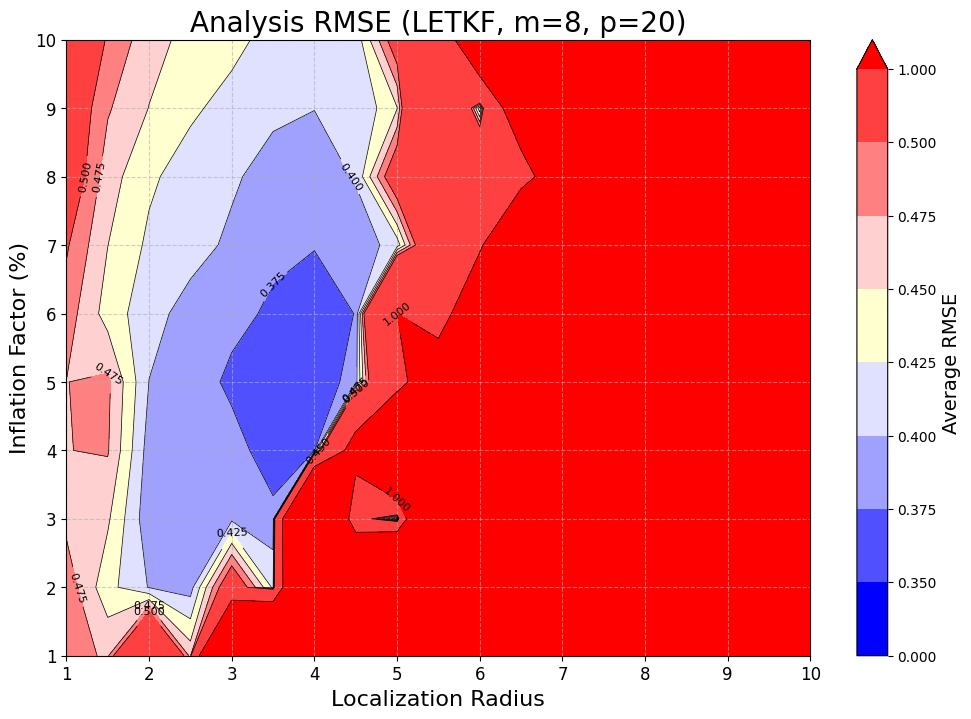

In [7]:
# データの読み込み
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

member_size = 8  # メンバー数を固定
n_obs = 20  # 観測変数の数

with open(f'enkf_letkf_rmse_matrix_m{member_size}_p{n_obs}.npy', 'rb') as f:
    rmse_matrix = np.load(f)

# rmse_matrixを出力
print("RMSE Matrix:")
print(rmse_matrix)

# パラメータリスト
inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(2, 21)]  # 1から10.0まで0.5刻み

# 1. 色と境界値の定義
colors = ['#0000ff', '#5050ff', '#a0a0ff', '#e0e0ff', '#ffffd0', '#ffd0d0', '#ff8080', '#ff4040', '#ff0000']
bounds = [0, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5, 1]

# 2. カスタムカラーマップと正規化オブジェクトを作成
cmap = ListedColormap(colors)
cmap.set_over('#ff0000') # 1.0を超える値を赤色に設定
norm = BoundaryNorm(bounds, cmap.N, extend='max')

# 3. メッシュグリッドの作成
X, Y = np.meshgrid(loc_radius_list, [(inf-1)*100 for inf in inflation_factors])

# 4. 等高線図の描画
plt.figure(figsize=(12, 8))

# 塗りつぶし等高線
contourf = plt.contourf(X, Y, rmse_matrix, levels=bounds, cmap=cmap, norm=norm, extend='max')

# 等高線
contour = plt.contour(X, Y, rmse_matrix, levels=bounds, colors='black', linewidths=0.5)

# 等高線ラベル
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.3f')

# カラーバー
cbar = plt.colorbar(contourf, ticks=bounds)
cbar.set_label('Average RMSE', fontsize=14)

# タイトルと軸ラベル
plt.title(f'Analysis RMSE (LETKF, m={member_size}, p={n_obs})', fontsize=20)
plt.xlabel('Localization Radius', fontsize=16)
plt.ylabel('Inflation Factor (%)', fontsize=16)

# 描画範囲の設定
plt.xlim(1, 10)

# 軸の目盛り設定
plt.xticks(np.arange(1, 11, 1), fontsize=12)
plt.yticks(np.arange(1, 11, 1), fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 観測の疎密による感度の違い

In [4]:
# 観測点数（num_obs）を引数に受け取る様式に修正した実験セル（セル9）
import numpy as np
from joblib import Parallel, delayed
import itertools

inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(2, 21)]  # 1から10.0まで0.5刻み
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 8  # メンバー数を固定
num_obs_list = [20, 25, 30, 35, 40]
# 全 num_obs に対する結果を格納する辞書

# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(38)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除

# ワーカー関数（num_obs を引数で受け取る）
def run_simulation(inflation_factor, loc_radius, num_obs):
    initial_state = spinup.x.copy()
    H = make_homogeneous_H(n=N, p=num_obs)
    enkf = EnKF_LETKF(N=N, F=F, H=H, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=inflation_factor, loc_radius=loc_radius)
    enkf.initialize_ensemble(initial_state)

    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf.forecast()
        enkf.analysis(observed_states[t])

    rmse = enkf.calculate_rmse(true_states)
    spread = enkf.calculate_spread()

    # 期間平均（例：90日目〜365日目）を取る
    start_idx = int(90 * (step_day / dt) / steps_per_assim)
    end_idx = int(365 * (step_day / dt) / steps_per_assim) - 1
    avg_rmse = np.mean(rmse[start_idx:end_idx])

    return inflation_factor, loc_radius, num_obs, avg_rmse, rmse, spread

# num_obsごとに並列実行を回す
param_combinations = list(itertools.product(inflation_factors, loc_radius_list))
for num_obs in num_obs_list:
    print(f"Starting experiments for num_obs = {num_obs} (members={member_size})")
    rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))

    # 並列実行（マシン負荷が高くなるため n_jobs は適宜調整してください）
    results = Parallel(n_jobs=-1)(delayed(run_simulation)(inf, loc, num_obs) for inf, loc in param_combinations)

    # 集約
    inf_map = {val: i for i, val in enumerate(inflation_factors)}
    loc_map = {val: j for j, val in enumerate(loc_radius_list)}

    results_dict = {}
    for inflation_factor, loc_radius, p_obs, avg_rmse, rmse_list, spread_list in results:
        i = inf_map[inflation_factor]
        j = loc_map[loc_radius]
        rmse_matrix[i, j] = avg_rmse
        results_dict[(inflation_factor, loc_radius)] = {'rmse': rmse_list, 'spread': spread_list}

    # 保存（num_obs をファイル名に含める）
    filename = f'enkf_letkf_rmse_matrix_m{member_size}_p{num_obs}homogeneous.npy'
    with open(filename, 'wb') as f:
        np.save(f, rmse_matrix)
    print(f"Finished experiments for num_obs = {num_obs}, saved {filename}")

Random steps for spinup: 1441
Starting experiments for num_obs = 20 (members=8)
Finished experiments for num_obs = 20, saved enkf_letkf_rmse_matrix_m8_p20homogeneous.npy
Starting experiments for num_obs = 25 (members=8)
Finished experiments for num_obs = 20, saved enkf_letkf_rmse_matrix_m8_p20homogeneous.npy
Starting experiments for num_obs = 25 (members=8)
Finished experiments for num_obs = 25, saved enkf_letkf_rmse_matrix_m8_p25homogeneous.npy
Starting experiments for num_obs = 30 (members=8)
Finished experiments for num_obs = 25, saved enkf_letkf_rmse_matrix_m8_p25homogeneous.npy
Starting experiments for num_obs = 30 (members=8)
Finished experiments for num_obs = 30, saved enkf_letkf_rmse_matrix_m8_p30homogeneous.npy
Starting experiments for num_obs = 35 (members=8)
Finished experiments for num_obs = 30, saved enkf_letkf_rmse_matrix_m8_p30homogeneous.npy
Starting experiments for num_obs = 35 (members=8)
Finished experiments for num_obs = 35, saved enkf_letkf_rmse_matrix_m8_p35homoge

In [6]:
# 観測点数（num_obs）を引数に受け取る様式に修正した実験セル（セル9）
import numpy as np
from joblib import Parallel, delayed
import itertools
import traceback

inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(2, 21)]  # 1から10.0まで0.5刻み
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 8  # メンバー数を固定
num_obs_list = [20, 25, 30, 35, 40]
# 全 num_obs に対する結果を格納する辞書

# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(38)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除

# ワーカー関数（num_obs を引数で受け取る）
def run_simulation(inflation_factor, loc_radius, num_obs):
    try:
        initial_state = spinup.x.copy()
        H = make_dense_H(n=N, p=num_obs)
        enkf = EnKF_LETKF(N=N, F=F, H=H, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=inflation_factor, loc_radius=loc_radius)
        enkf.initialize_ensemble(initial_state)

        for t in range(0, observed_states.shape[0], steps_per_assim):
            enkf.forecast()
            enkf.analysis(observed_states[t])

        rmse = enkf.calculate_rmse(true_states)
        spread = enkf.calculate_spread()

        # 期間平均（例：90日目〜365日目）を取る
        start_idx = int(90 * (step_day / dt) / steps_per_assim)
        end_idx = int(365 * (step_day / dt) / steps_per_assim) - 1
        avg_rmse = np.mean(rmse[start_idx:end_idx])

        return inflation_factor, loc_radius, num_obs, avg_rmse, rmse, spread
    except Exception as e:
        print(f"Error in simulation (inf={inflation_factor}, loc={loc_radius}, num_obs={num_obs}): {e}")
        # traceback.print_exc() # 必要に応じて詳細なトレースバックを表示
        # エラー時は NaN を返す
        return inflation_factor, loc_radius, num_obs, np.nan, [np.nan], [np.nan]

# num_obsごとに並列実行を回す
param_combinations = list(itertools.product(inflation_factors, loc_radius_list))
for num_obs in num_obs_list:
    print(f"Starting experiments for num_obs = {num_obs} (members={member_size})")
    rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))

    # 並列実行（マシン負荷が高くなるため n_jobs は適宜調整してください）
    results = Parallel(n_jobs=-1)(delayed(run_simulation)(inf, loc, num_obs) for inf, loc in param_combinations)

    # 集約
    inf_map = {val: i for i, val in enumerate(inflation_factors)}
    loc_map = {val: j for j, val in enumerate(loc_radius_list)}

    results_dict = {}
    for inflation_factor, loc_radius, p_obs, avg_rmse, rmse_list, spread_list in results:
        i = inf_map[inflation_factor]
        j = loc_map[loc_radius]
        rmse_matrix[i, j] = avg_rmse
        results_dict[(inflation_factor, loc_radius)] = {'rmse': rmse_list, 'spread': spread_list}

    # 保存（num_obs をファイル名に含める）
    filename = f'enkf_letkf_rmse_matrix_m{member_size}_p{num_obs}dense.npy'
    with open(filename, 'wb') as f:
        np.save(f, rmse_matrix)
    print(f"Finished experiments for num_obs = {num_obs}, saved {filename}")

Random steps for spinup: 1441
Starting experiments for num_obs = 20 (members=8)
Finished experiments for num_obs = 20, saved enkf_letkf_rmse_matrix_m8_p20dense.npy
Starting experiments for num_obs = 25 (members=8)
Finished experiments for num_obs = 20, saved enkf_letkf_rmse_matrix_m8_p20dense.npy
Starting experiments for num_obs = 25 (members=8)
Finished experiments for num_obs = 25, saved enkf_letkf_rmse_matrix_m8_p25dense.npy
Starting experiments for num_obs = 30 (members=8)
Finished experiments for num_obs = 25, saved enkf_letkf_rmse_matrix_m8_p25dense.npy
Starting experiments for num_obs = 30 (members=8)
Finished experiments for num_obs = 30, saved enkf_letkf_rmse_matrix_m8_p30dense.npy
Starting experiments for num_obs = 35 (members=8)
Finished experiments for num_obs = 30, saved enkf_letkf_rmse_matrix_m8_p30dense.npy
Starting experiments for num_obs = 35 (members=8)
Finished experiments for num_obs = 35, saved enkf_letkf_rmse_matrix_m8_p35dense.npy
Starting experiments for num_obs

In [7]:
# 3DVARクラスの定義
class ThreeDVar:
    """
    3次元変分法 (3DVAR) クラス
    """
    def __init__(self, N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, H=None, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0):
        """
        3次元変分法の初期化

        Parameters:
        -----------
        N : int
            状態変数の数
        F : float
            外部強制力
        dt : float
            時間ステップ
        H : ndarray
            観測演算子
        obs_error_std : float
            観測誤差の標準偏差
        forecast_error_std : float
            予報誤差の標準偏差(定数として使用可能)
        model_error_std : float
            モデル誤差の標準偏差
        use_constant_P : bool
            予報誤差共分散を定数として扱うか(True=3次元変分法と同値)
        method : str
            時間積分メソッド ('euler', 'rk2', 'rk4')
        way : str
            接線線形演算子の計算方法 ('Numerical', 'Mathematical')
        delta : float
            接線線形演算子の数値微分の差分幅(ヤコビ行列計算用)
        inflation_factor : float
            予報誤差共分散行列のインフレーション係数
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.obs_error_std = obs_error_std
        self.forecast_error_std = forecast_error_std
        self.H = H
        self.use_constant_P = use_constant_P
        self.method = method
        self.way = way
        self.delta = delta
        self.inflation_factor = inflation_factor

        # StateArrayクラスのインスタンス化
        self.state_array = StateArray(N, F, dt, method=method)
        
        # 観測誤差共分散行列
        self.R = obs_error_std * np.eye(N)
        
        # 予報誤差共分散行列
        self.P_analysis = forecast_error_std * np.eye(N)
        self.P_forecast = None
        self.P_constant = forecast_error_std * np.eye(N)  # 定数として保存
        
        
        # 状態変数の初期化
        self.x_analysis = None
        self.x_forecast = None
        
        # 履歴の保存
        self.analysis_history = []
        self.forecast_history = []
        self.innovation_history = []
        self.P_history = []  # 予報誤差共分散行列の履歴
        
    def initialize_state(self, x0):
        """
        初期状態の設定
        
        Parameters:
        -----------
        x0 : ndarray
            初期状態ベクトル
        """
        self.x_analysis = x0.copy()
        if self.H.any():
            self.R = self.obs_error_std * np.eye(self.H.shape[0])
        
    def compute_tangent_linear(self, x, way='Numerical'):
        """
        Lorenz96モデルの接線形演算子(ヤコビ行列)を計算
        
        Parameters:
        -----------
        x : ndarray
            状態ベクトル
            
        Returns:
        --------
        M : ndarray
            接線形演算子行列
        """
        if way == 'Numerical':
            N = len(x)
            M = np.zeros((N, N))
            e = np.eye(N)
            delta = self.delta
            temp_state = StateArray(N, self.F, self.dt, method=self.method)
            temp_state.x = x.copy()
            temp_state.step()
            f = temp_state.x.copy()
            for i in range(N):
                x_plus = x.copy()
                x_plus += delta * e[:, i]
                temp_state.x = x_plus.copy()
                temp_state.step()
                f_plus = temp_state.x.copy()

                M[:, i] = (f_plus - f) / delta
            
            return M
        
        elif way == 'Mathematical':
            N = len(x)
            M = np.zeros((N, N))
            
            for i in range(N):
                # ∂f_i/∂x_{i-2}
                M[i, i-2] = -x[i-1]
                # ∂f_i/∂x_{i-1}
                M[i, i-1] = x[(i+1)%N] - x[i-2]
                # ∂f_i/∂x_i
                M[i, i] = -1.0
                # ∂f_i/∂x_{i+1}
                M[i, (i+1)%N] = x[i-1]
            
            # 接線形演算子: I + dt*M (1次近似)
            return np.eye(N) + self.dt * M
    
    def forecast(self, steps):
        """
        予報ステップ
        
        Parameters:
        -----------
        steps : int
            時間積分のステップ数
        """

        # StateArrayを使って状態ベクトルの時間積分
        self.state_array.x = self.x_analysis.copy()
        
        for _ in range(steps):
            self.state_array.step()
        
        self.x_forecast = self.state_array.x.copy()
        
        if not self.use_constant_P:
            # 接線形演算子の計算と合成
            x_temp = self.x_analysis.copy()
            
            for _ in range(steps):
                M = self.compute_tangent_linear(x_temp, way=self.way)
                # StateArrayを使って次のステップへ
                temp_state = StateArray(self.N, self.F, self.dt, method=self.method)
                temp_state.x = x_temp.copy()
                temp_state.step()
                x_temp = temp_state.x.copy()
            
            # 予報誤差共分散行列の更新
            self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
        else:
            # 定数として扱う場合(3次元変分法と同値)
            self.P_forecast = self.P_constant.copy()
        
        self.forecast_history.append(self.x_forecast.copy())
        self.P_history.append(self.P_forecast.copy())  # 予報誤差共分散行列を保存
        
    def analysis(self, observation, H=None):
        """
        解析ステップ
        
        Parameters:
        -----------
        observation : ndarray
            観測ベクトル
        H : ndarray, optional
            観測演算子(デフォルトは単位行列=全変数を観測)
        """
        if H is None:
            H = np.eye(self.N)
        
        # カルマンゲインの計算
        HPH = H @ self.P_forecast @ H.T
        K = self.P_forecast @ H.T @ np.linalg.inv(HPH + self.R)

        # イノベーション(観測と予報の差)
        innovation = H @ observation - H @ self.x_forecast
        self.innovation_history.append(innovation.copy())
        
        # 解析値の計算
        self.x_analysis = self.x_forecast + K @ innovation
        
        if not self.use_constant_P:
            # 解析誤差共分散行列の更新
            self.P_analysis = (np.eye(self.N) - K @ H) @ self.P_forecast
        
        self.analysis_history.append(self.x_analysis.copy())
        
    def assimilate(self, observation, steps, H=None):
        """
        1サイクルのデータ同化(予報→解析)
        
        Parameters:
        -----------
        observation : ndarray
            観測ベクトル
        steps : int
            予報の時間積分ステップ数
        H : ndarray, optional
            観測演算子
        """
        self.forecast(steps)
        self.analysis(observation, H)
        
    def get_analysis_array(self):
        """解析値の履歴を配列として取得"""
        return np.array(self.analysis_history)
    
    def get_forecast_array(self):
        """予報値の履歴を配列として取得"""
        return np.array(self.forecast_history)
    
    def get_innovation_array(self):
        """イノベーションの履歴を配列として取得"""
        return np.array(self.innovation_history)
    
    def compute_rmse(self, true_states):
        """
        RMSEを計算
        
        Parameters:
        -----------
        true_states : ndarray
            真値の配列
            
        Returns:
        --------
        rmse_analysis : ndarray
            解析値のRMSE
        rmse_forecast : ndarray
            予報値のRMSE
        """
        analysis_array = self.get_analysis_array()
        forecast_array = self.get_forecast_array()
        
        rmse_analysis = np.sqrt(np.mean((analysis_array - true_states)**2, axis=1))
        rmse_forecast = np.sqrt(np.mean((forecast_array - true_states)**2, axis=1))
        
        return rmse_analysis, rmse_forecast
    
    def get_P_history(self):
        """予報誤差共分散行列の履歴を取得(保存されている場合)"""
        if hasattr(self, 'P_history'):
            return self.P_history
        else:
            return None
    
    def compute_spread(self):
        """
        Spreadを計算(予報誤差共分散行列の対角成分の平方根の平均)
        
        Returns:
        --------
        spread : ndarray
            各サイクルにおけるSpread
        """
        if hasattr(self, 'P_history') and len(self.P_history) > 0:
            spread = np.array([np.sqrt(np.trace(P)/self.N) for P in self.P_history])
            return spread
        else:
            print("Warning: P_history not available. Spread cannot be computed.")
            return None
        

In [13]:
# ETFと3DVARの観測地点数を変化させた場合の10-300daysの平均RMSEを計算し、プロットするコード
# 観測データの読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む

# パラメータ設定
N = 40
F = 8.0
dt = 0.05
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# Store results for all inflation factors
results_dict = {}

p_values = [20, 25, 30, 35, 40]

for p in p_values:
    print(f"\n=== Number of Observations: {p} ===")
    H = make_homogeneous_H(n=N, p=p)
    # ThreeDVarインスタンスの作成
    three_d_var = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=0.26, H=H, use_constant_P=True, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0)
    # Extended Kalman Filterインスタンスの作成
    etf = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, H=H, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.1)

    # 初期状態の設定
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    three_d_var.initialize_state(spinup.x.copy())
    etf.initialize_state(spinup.x.copy())
    # データ同化の実行
    num_assim = len(observed_states)
    for k in range(num_assim):
        three_d_var.assimilate(observed_states[k], steps_per_assim, H)
        etf.assimilate(observed_states[k], steps_per_assim, H)
        if (k % 100) == 0:
            print(f"Assimilating cycle {k}/{num_assim}")
    # RMSEの計算
    rmse_analysis_3dvar, rmse_forecast_3dvar = three_d_var.compute_rmse(true_states)
    rmse_analysis_etf, rmse_forecast_etf = etf.compute_rmse(true_states)
    # 結果を保存
    results_dict[p] = {
        'rmse_analysis_3dvar': rmse_analysis_3dvar,
        'rmse_forecast_3dvar': rmse_forecast_3dvar,
        'rmse_analysis_etf': rmse_analysis_etf,
        'rmse_forecast_etf': rmse_forecast_etf
    }

# 保存したresults_dictを使って10-300daysの平均RMSEを計算し、それぞれmin_rmse_values_3dvarとmin_rmse_values_etfに格納
min_rmse_values_3dvar = []
min_rmse_values_etf = []
for p in p_values:
    data = results_dict[p]
    rmse_analysis_3dvar = data['rmse_analysis_3dvar']
    rmse_analysis_etf = data['rmse_analysis_etf']
    
    start_idx = int(10 * (step_day / dt) / steps_per_assim)
    end_idx = int(300 * (step_day / dt) / steps_per_assim) - 1
    avg_rmse_3dvar = np.mean(rmse_analysis_3dvar[start_idx:end_idx])
    avg_rmse_etf = np.mean(rmse_analysis_etf[start_idx:end_idx])
    min_rmse_values_3dvar.append(avg_rmse_3dvar)
    min_rmse_values_etf.append(avg_rmse_etf)


=== Number of Observations: 20 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 25 ===
Assimilating cycle 1400/1460

=== Number of Observations: 25 ===
Assimilating cycle 0/1460
Assimilating cycle 0/1460
Assimilating cycle 1

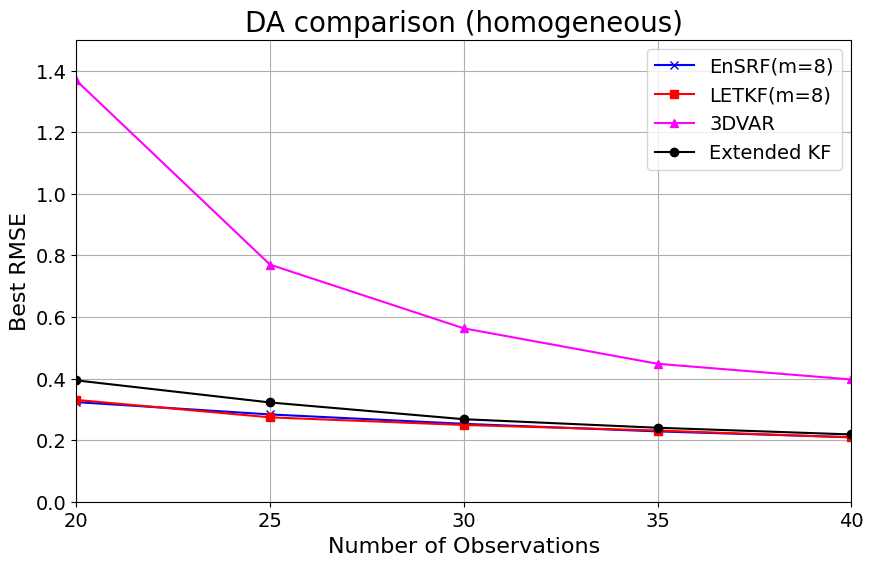

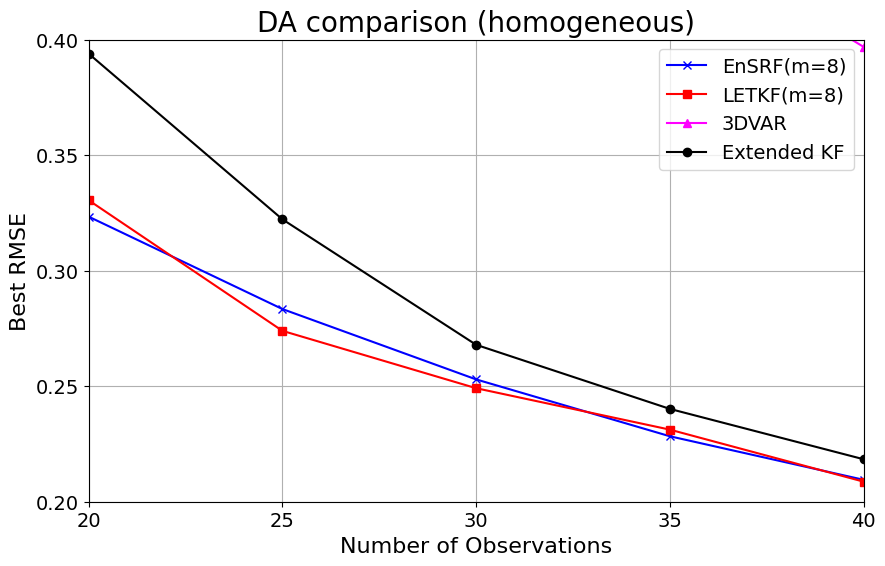

In [14]:
# member_size = 8でメンバー数を固定し、観測点数を変化させた場合のrmse_matrixを読み込み、観測点数ごとの最小のRMSE(Nanを除く)をプロットするコード
import numpy as np
member_size = 8  # メンバー数を固定
n_obs_list = [20, 25, 30, 35, 40]  # 観測変数の数のリスト
min_rmse_values_EnSRF = []
min_rmse_values_LETKF = []
for n_obs in n_obs_list:
    with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{n_obs}homogeneous.npy', 'rb') as f:
        rmse_matrix = np.load(f)
    # NaNを除いた最小値を計算
    min_rmse = np.nanmin(rmse_matrix)
    min_rmse_values_EnSRF.append(min_rmse)
    with open(f'enkf_letkf_rmse_matrix_m{member_size}_p{n_obs}homogeneous.npy', 'rb') as f:
        rmse_matrix_letkf = np.load(f)
    min_rmse_letkf = np.nanmin(rmse_matrix_letkf)
    min_rmse_values_LETKF.append(min_rmse_letkf)

# 横軸: 観測点数、縦軸: 最小RMSEのプロット
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(n_obs_list, min_rmse_values_EnSRF, marker='x', linestyle='-', color='blue', label=f'EnSRF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_LETKF, marker='s', linestyle='-', color='red', label=f'LETKF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_3dvar, marker='^', linestyle='-', color='magenta', label='3DVAR')
plt.plot(n_obs_list, min_rmse_values_etf, marker='o', linestyle='-', color='black', label='Extended KF')
plt.title(f'DA comparison (homogeneous)', fontsize=20)
plt.xlabel('Number of Observations', fontsize=16)
plt.ylabel('Best RMSE', fontsize=16)
plt.xticks(n_obs_list, fontsize=14)
plt.yticks(np.arange(0, 1.6, 0.2), fontsize=14)
plt.xlim(min(n_obs_list), max(n_obs_list))
plt.ylim(0, 1.5)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

# 同様のプロットを0.2から0.4までの範囲で拡大して表示するコード
plt.figure(figsize=(10, 6))
plt.plot(n_obs_list, min_rmse_values_EnSRF, marker='x', linestyle='-', color='blue', label=f'EnSRF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_LETKF, marker='s', linestyle='-', color='red', label=f'LETKF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_3dvar, marker='^', linestyle='-', color='magenta', label='3DVAR')
plt.plot(n_obs_list, min_rmse_values_etf, marker='o', linestyle='-', color='black', label='Extended KF')
plt.title(f'DA comparison (homogeneous)', fontsize=20)
plt.xlabel('Number of Observations', fontsize=16)
plt.ylabel('Best RMSE', fontsize=16)
plt.xticks(n_obs_list, fontsize=14)
plt.yticks(np.arange(0.2, 0.45, 0.05), fontsize=14)
plt.xlim(min(n_obs_list), max(n_obs_list))
plt.ylim(0.2, 0.4)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

In [15]:
# ETFと3DVARの観測地点数を変化させた場合の10-300daysの平均RMSEを計算し、プロットするコード
# 観測データの読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む

# パラメータ設定
N = 40
F = 8.0
dt = 0.05
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# Store results for all inflation factors
results_dict = {}

p_values = [20, 25, 30, 35, 40]

for p in p_values:
    print(f"\n=== Number of Observations: {p} ===")
    H = make_dense_H(n=N, p=p)
    # ThreeDVarインスタンスの作成
    three_d_var = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=0.26, H=H, use_constant_P=True, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0)
    # Extended Kalman Filterインスタンスの作成
    etf = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, H=H, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.1)

    # 初期状態の設定
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    three_d_var.initialize_state(spinup.x.copy())
    etf.initialize_state(spinup.x.copy())
    # データ同化の実行
    num_assim = len(observed_states)
    for k in range(num_assim):
        three_d_var.assimilate(observed_states[k], steps_per_assim, H)
        etf.assimilate(observed_states[k], steps_per_assim, H)
        if (k % 100) == 0:
            print(f"Assimilating cycle {k}/{num_assim}")
    # RMSEの計算
    rmse_analysis_3dvar, rmse_forecast_3dvar = three_d_var.compute_rmse(true_states)
    rmse_analysis_etf, rmse_forecast_etf = etf.compute_rmse(true_states)
    # 結果を保存
    results_dict[p] = {
        'rmse_analysis_3dvar': rmse_analysis_3dvar,
        'rmse_forecast_3dvar': rmse_forecast_3dvar,
        'rmse_analysis_etf': rmse_analysis_etf,
        'rmse_forecast_etf': rmse_forecast_etf
    }

# 保存したresults_dictを使って10-300daysの平均RMSEを計算し、それぞれmin_rmse_values_3dvarとmin_rmse_values_etfに格納
min_rmse_values_3dvar = []
min_rmse_values_etf = []
for p in p_values:
    data = results_dict[p]
    rmse_analysis_3dvar = data['rmse_analysis_3dvar']
    rmse_analysis_etf = data['rmse_analysis_etf']
    
    start_idx = int(10 * (step_day / dt) / steps_per_assim)
    end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
    avg_rmse_3dvar = np.mean(rmse_analysis_3dvar[start_idx:end_idx])
    avg_rmse_etf = np.mean(rmse_analysis_etf[start_idx:end_idx])
    min_rmse_values_3dvar.append(avg_rmse_3dvar)
    min_rmse_values_etf.append(avg_rmse_etf)


=== Number of Observations: 20 ===
Assimilating cycle 0/1460


C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_22068\1757141609.py:16: RuntimeWarning: overflow encountered in multiply
  return (roll_p1 - roll_m2) * roll_m1 - x + F
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_22068\4194845163.py:114: RuntimeWarning: invalid value encountered in subtract
  M[:, i] = (f_plus - f) / delta
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_22068\4194845163.py:166: RuntimeWarning: overflow encountered in matmul
  self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_22068\4194845163.py:166: RuntimeWarning: invalid value encountered in matmul
  self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_22068\4194845163.py:193: RuntimeWarning: invalid value encountered in matmul
  innovation = H @ observation - H @ self.x_forecast


Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460
Assimilating cycle 1400/1460


C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_22068\4194845163.py:253: RuntimeWarning: overflow encountered in square
  rmse_forecast = np.sqrt(np.mean((forecast_array - true_states)**2, axis=1))



=== Number of Observations: 25 ===
Assimilating cycle 0/1460


C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_22068\1757141609.py:16: RuntimeWarning: invalid value encountered in subtract
  return (roll_p1 - roll_m2) * roll_m1 - x + F
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_22068\1757141609.py:39: RuntimeWarning: invalid value encountered in add
  return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6


Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 30 ===
Assimilating cycle 1400/1460

=== Number of Observations: 30 ===
Assimilating cycle 0/1460
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 200/146

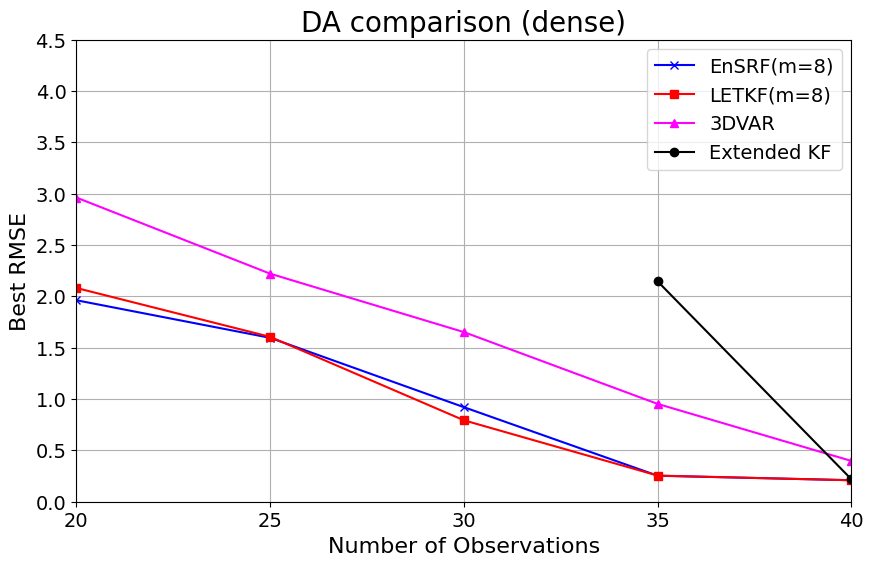

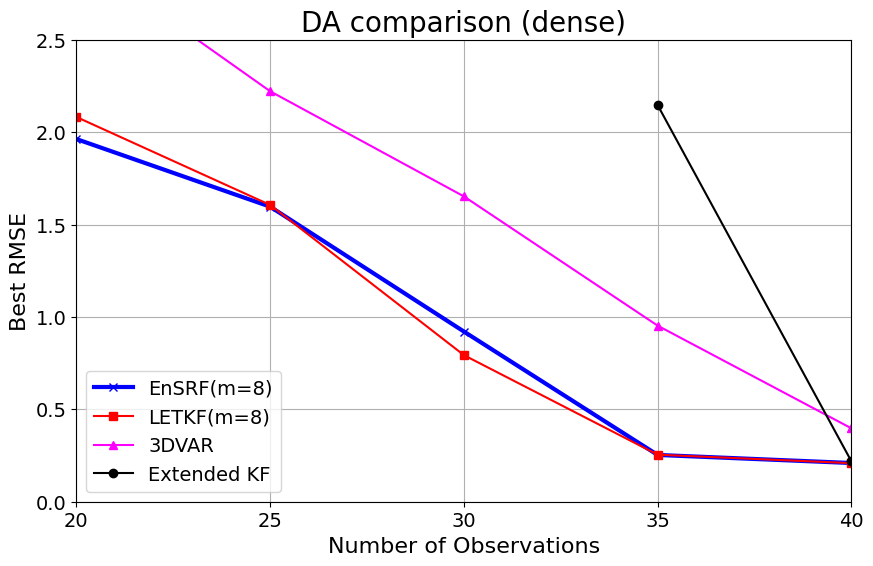

In [19]:
# member_size = 8でメンバー数を固定し、観測点数を変化させた場合のrmse_matrixを読み込み、観測点数ごとの最小のRMSE(Nanを除く)をプロットするコード
import numpy as np
member_size = 8  # メンバー数を固定
n_obs_list = [20, 25, 30, 35, 40]  # 観測変数の数のリスト
min_rmse_values_EnSRF = []
min_rmse_values_LETKF = []
for n_obs in n_obs_list:
    with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{n_obs}dense.npy', 'rb') as f:
        rmse_matrix = np.load(f)
    # NaNを除いた最小値を計算
    min_rmse = np.nanmin(rmse_matrix)
    min_rmse_values_EnSRF.append(min_rmse)
    with open(f'enkf_letkf_rmse_matrix_m{member_size}_p{n_obs}dense.npy', 'rb') as f:
        rmse_matrix_letkf = np.load(f)
    min_rmse_letkf = np.nanmin(rmse_matrix_letkf)
    min_rmse_values_LETKF.append(min_rmse_letkf)

# 横軸: 観測点数、縦軸: 最小RMSEのプロット
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(n_obs_list, min_rmse_values_EnSRF, marker='x', linestyle='-', color='blue', label=f'EnSRF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_LETKF, marker='s', linestyle='-', color='red', label=f'LETKF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_3dvar, marker='^', linestyle='-', color='magenta', label='3DVAR')
plt.plot(n_obs_list, min_rmse_values_etf, marker='o', linestyle='-', color='black', label='Extended KF')
plt.title(f'DA comparison (dense)', fontsize=20)
plt.xlabel('Number of Observations', fontsize=16)
plt.ylabel('Best RMSE', fontsize=16)
plt.xticks(n_obs_list, fontsize=14)
plt.yticks(np.arange(0, 5, 0.5), fontsize=14)
plt.xlim(min(n_obs_list), max(n_obs_list))
plt.ylim(0, 4.5)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

# 同様のプロットを0から2.5までの範囲で拡大して表示するコード
plt.figure(figsize=(10, 6))
plt.plot(n_obs_list, min_rmse_values_EnSRF, marker='x', linestyle='-', color='blue', label=f'EnSRF(m={member_size})', linewidth=3)
plt.plot(n_obs_list, min_rmse_values_LETKF, marker='s', linestyle='-', color='red', label=f'LETKF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_3dvar, marker='^', linestyle='-', color='magenta', label='3DVAR')
plt.plot(n_obs_list, min_rmse_values_etf, marker='o', linestyle='-', color='black', label='Extended KF')
plt.title(f'DA comparison (dense)', fontsize=20)
plt.xlabel('Number of Observations', fontsize=16)
plt.ylabel('Best RMSE', fontsize=16)
plt.xticks(n_obs_list, fontsize=14)
plt.yticks(np.arange(0, 2.6, 0.5), fontsize=14)
plt.xlim(min(n_obs_list), max(n_obs_list))
plt.ylim(0, 2.5)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()